In [1]:
import torch, torchvision # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split, GroupKFold, StratifiedKFold

from PIL import Image
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json, math, datetime, random, gc, ast
import numpy  as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from time import time
from utils.index import *
from tqdm import tqdm

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import nms

from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SequentialSampler

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [2]:
MULTI_GPU = json.loads(open('../Task/info.json', 'r').read()).get('multi-gpu', False)
GPU_IDS   = getDevices(double=MULTI_GPU)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()

── GPU SETUP ──────────────────────────────────────
  torch      : 2.7.1+cu118 (cuda 11.8)
  alocador   : expandable_segments:True
  detectadas : 2
    [0] Quadro P6000 — 24 GB  (em uso)
    [1] Quadro P6000 — 24 GB  (em uso)
  modo       : DataParallel em 2 GPUs — 48 GB somados
  principal  : cuda:0
───────────────────────────────────────────────────


110

In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    np.random.default_rng(seed=seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print('random seed done')


seed_everything(42)

random seed done


In [4]:
OPTIONS = json.loads(open('../Task/info.json', 'r').read())
OPTIONS

{'network': 'resaceunet',
 'multi-gpu': True,
 'dataset': 'facies',
 'img_size': [4, 256, 256],
 'step': 3,
 'multiclass': True,
 'lr': 0.0005,
 'loss': 'dice_focal',
 'batch_size': 16,
 'scheduler': 'plateau',
 'dropout': 0.05,
 'num_filters': 32}

In [5]:
IMG_SIZE   = OPTIONS.get('img_size')
BATCH_SIZE = OPTIONS.get('batch_size')   # batch total; o DataParallel divide entre as GPUs
IMG_SIZE, BATCH_SIZE

([4, 256, 256], 16)

In [6]:
df = pd.read_csv('../Dataset/DataBase.csv')
IMG_SIZE = ast.literal_eval(df['shape'].iloc[0])
print(df.img_path.iloc[0])

OPTIONS['img_size'] = IMG_SIZE
df

/home/grva-mintcave/Projects/Facies/Dataset/facies/tiles/images/img_00000.npy


,img_path,mask_path,shape,min,max,mean,std,msk_max
0,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.229268,0.778868,0.502732,0.037087,3
1,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,0.937083,0.502533,0.038899,4
2,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.502285,0.046293,4
3,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.357488,0.732417,0.502492,0.019550,4
4,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.501868,0.083783,4
...,...,...,...,...,...,...,...,...
7069,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.497164,0.248731,5
7070,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.491530,0.283405,5
7071,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.500084,0.218975,5
7072,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.499803,0.119612,5


In [7]:
MULTICLASS = True
classes    = int(df['msk_max'].max()) + 1
classes

6

img: (np.float32(0.22926785), np.float32(0.7788685))
msk: (np.uint8(0), np.uint8(3))


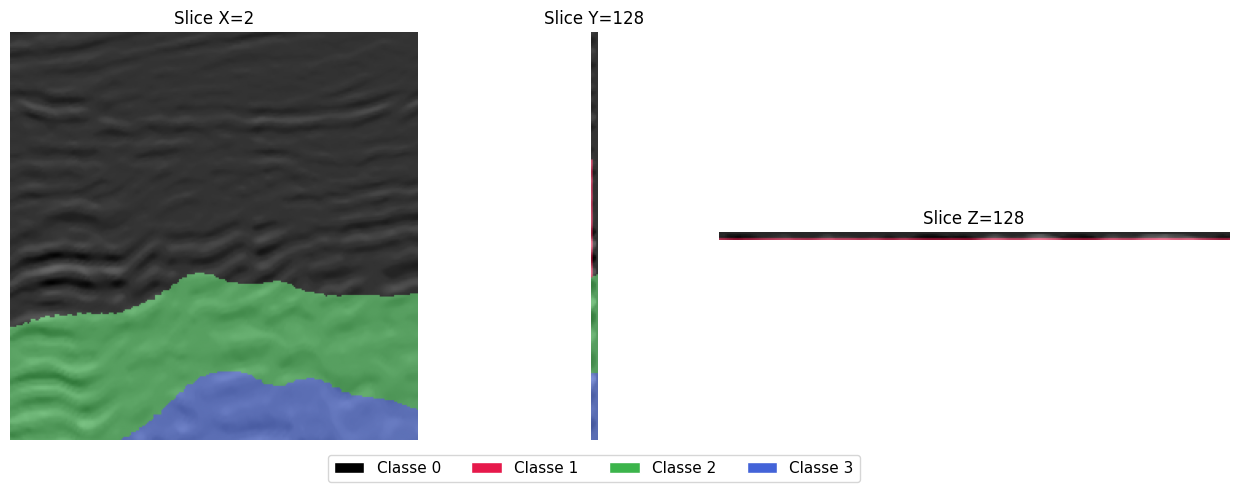

In [8]:
for index in range(1):
    img, msk = np.load(df.iloc[index].img_path), np.load(df.iloc[index].mask_path)
    print(f'img: {np.min(img), np.max(img)}')
    print(f'msk: {np.min(msk), np.max(msk)}')
    showTile(img=img, mask=msk)

# SPLITS DOS DADOS

In [9]:
VAL_SIZE  = 0.1
TEST_SIZE = 0.1
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [10]:
temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42)
train_df, val_df = train_test_split(temp_df, test_size=VAL_SIZE, random_state=42)
del temp_df

OPTIONS['n_images'] = {'total': len(df), 'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
OPTIONS['n_images']

{'total': 7074, 'train': 5658, 'val': 708, 'test': 708}

# MODELO

In [11]:
from Network.index import ModelNetwork

In [12]:
model_options = {
    'network': OPTIONS.get('network'),
    'img_size': IMG_SIZE,
    'classes': classes,
    'channels': 1,
    'dropout': OPTIONS.get('dropout'),
    'num_filters': OPTIONS.get('num_filters'),
    'lr': OPTIONS.get('lr'),
    'deep_supervision': OPTIONS.get('deep_supervision', False),
}

print(model_options)

# gpu_ids fora de model_options: esse dict vira o info.json que alimenta o Predict, que roda em uma GPU só
network = ModelNetwork(**model_options, gpu_ids=GPU_IDS)
network.model

{'network': 'resaceunet', 'img_size': (4, 256, 256), 'classes': 6, 'channels': 1, 'dropout': 0.05, 'num_filters': 32, 'lr': 0.0005, 'deep_supervision': False}


DataParallel(
  (module): ResACEUnet(
    (encoders): ModuleList(
      (0): EncoderStage(
        (blocks): Sequential(
          (0): ResACEBlock(
            (conv1): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
            (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
            (ace): ACE3D(
              (channel): ChannelAttention3D(
                (mlp): Sequential(
                  (0): Linear(in_features=32, out_features=8, bias=False)
                  (1): ReLU(inplace=True)
                  (2): Linear(in_features=8, out_features=32, bias=False)
                )
              )
              (spatial): SpatialGate3D(
                (conv): Conv3d(2, 1, kernel_size=(1, 7, 7), stride=(1, 1, 1), padding=(0, 3, 3), bias=False)
              )
            )
   

In [13]:
network.classes

6

# DATASET

In [14]:
from torch.utils.data import Dataset
from Transforms.index import Compose

In [15]:
class CustomDataset(Dataset):
    def __init__(self, df, multiclass=False, augmentations=None):
        self.df = df.reset_index(drop=True)
        self.multiclass = multiclass
        self.augmentor  = Compose(augmentations) if augmentations else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        if self.augmentor:
            img, mask = self.augmentor(img, mask)

        img_tensor  = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


trainDataset = CustomDataset(
    df=train_df,
    multiclass=MULTICLASS,
    augmentations=OPTIONS.get('augmentations')
)

valDataset = CustomDataset(
    df=val_df,
    multiclass=MULTICLASS
)

testDataset = CustomDataset(
    df=test_df,
    multiclass=MULTICLASS
)

# DATA LOADER

In [16]:
from torch.utils.data import DataLoader

In [17]:
NUM_WORKERS = 2 * max(len(GPU_IDS), 1)   # com mais GPUs o passo fica mais rápido, o loader precisa acompanhar

trainLoader = DataLoader(
    trainDataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

valLoader = DataLoader(
    valDataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

testLoader = DataLoader(
    testDataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

xTrain Shape:  (4, 256, 256)
yTrain Shape:  (4, 256, 256)
xTrain Range:  (0.0, 1.0)
yTrain Unique: [0 4 5]


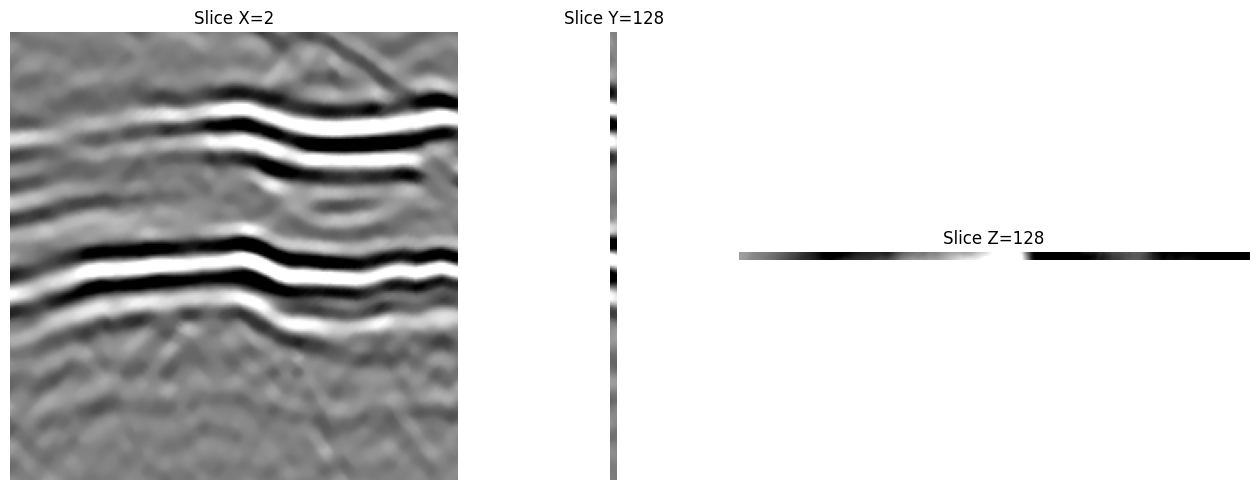

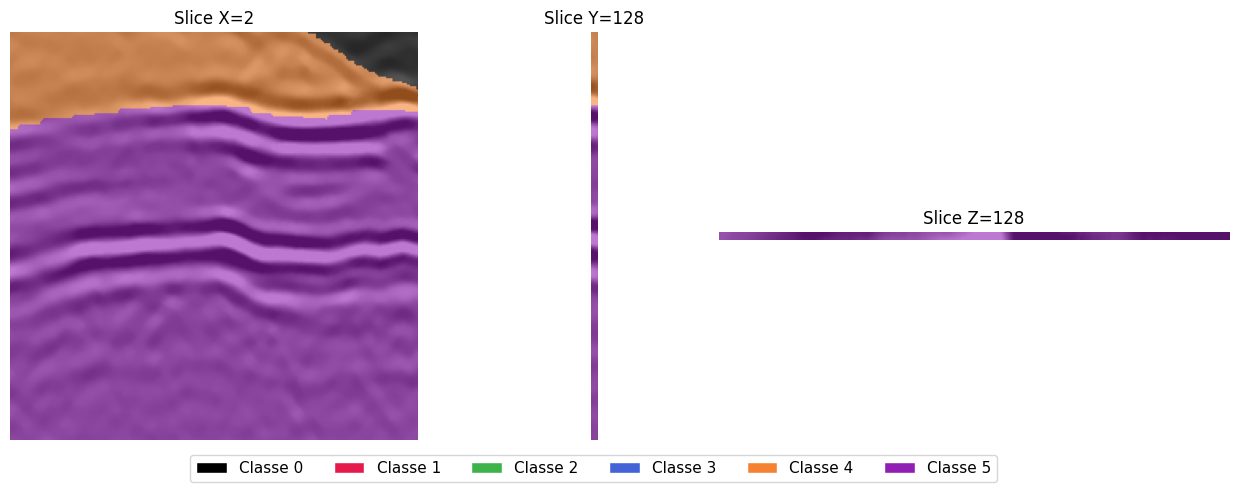

xTrain Shape:  (4, 256, 256)
yTrain Shape:  (4, 256, 256)
xTrain Range:  (0.0, 1.0)
yTrain Unique: [0 4 5]


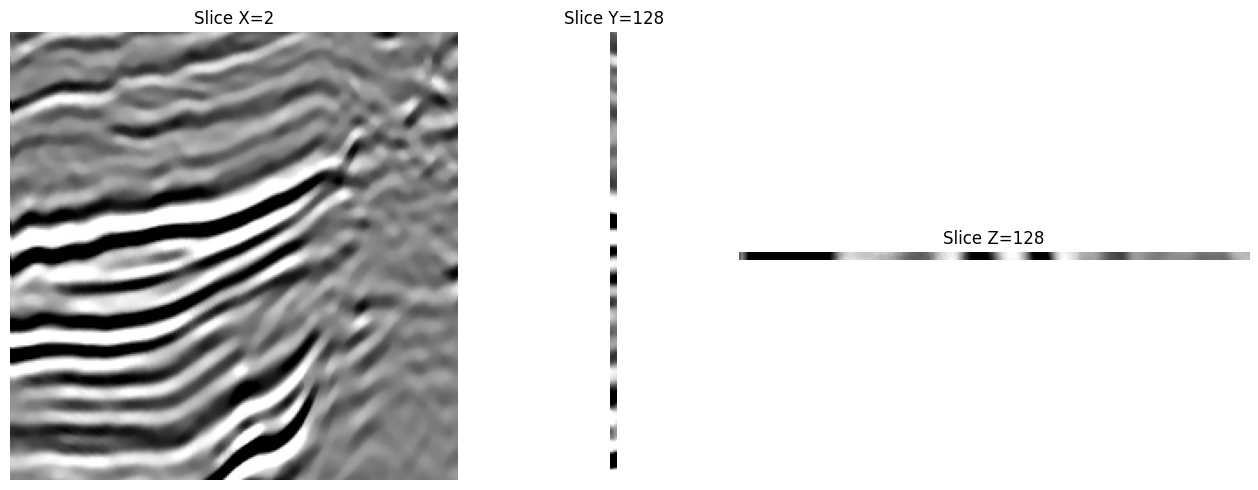

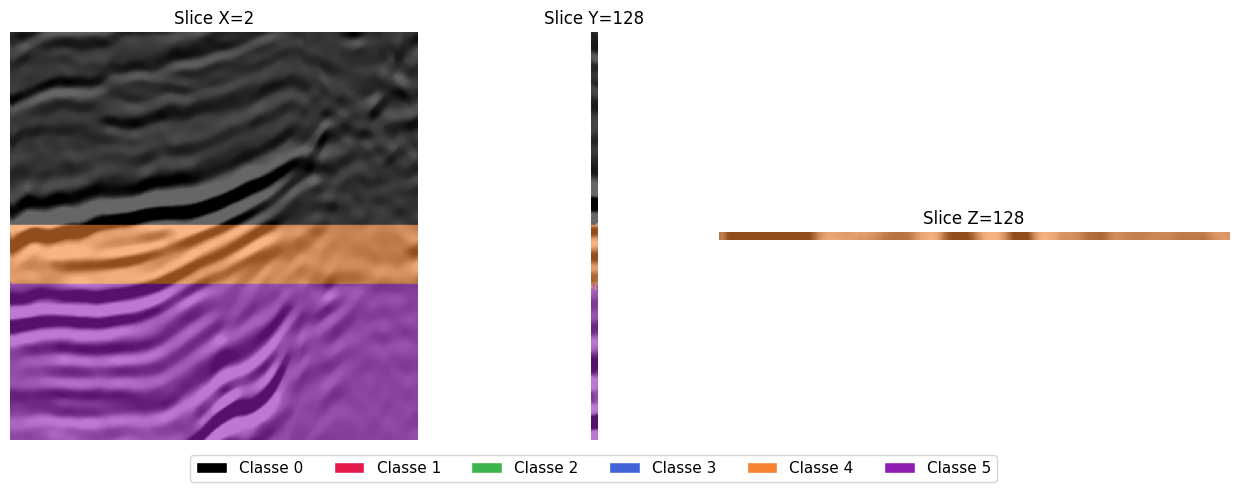

xTrain Shape:  (4, 256, 256)
yTrain Shape:  (4, 256, 256)
xTrain Range:  (0.0, 1.0)
yTrain Unique: [5]


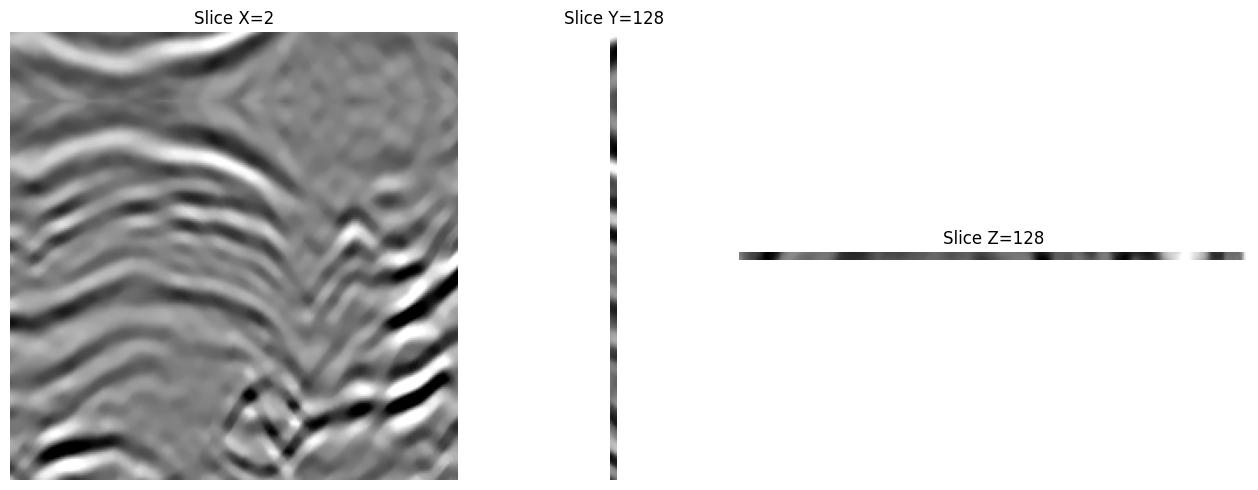

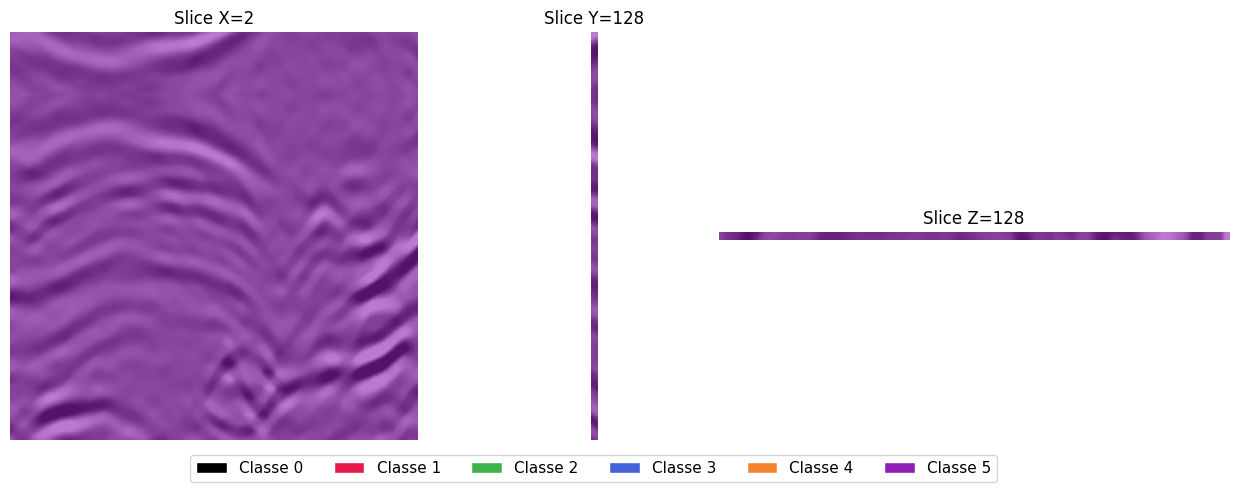

In [18]:
for i in range(min(3, BATCH_SIZE)):
    images, masks = next(iter(trainLoader))
    img = images[i].squeeze().cpu().numpy()
    msk = masks[i].squeeze().cpu().numpy()

    print('xTrain Shape: ', img.shape)
    print('yTrain Shape: ', msk.shape)
    print('xTrain Range: ', (float(np.min(img)), float(np.max(img))))
    print('yTrain Unique:', np.unique(msk).astype(int))

    showTile(img)
    showTile(img=img, mask=msk)

# TREINAMENTO

### Losses

In [19]:
from Losses.index import Losses
from EarlyStopping.index import EarlyStopping
from torch import amp
gc.collect()

26031

In [20]:
selected_loss = OPTIONS.get('loss')
loss = Losses(selected_loss, multiclass=network.multiclass)
loss

MultiClassDiceFocalLoss(
  (_loss): DiceFocalLoss(
    (dice): DiceLoss()
    (focal): FocalLoss()
  )
)

### Scheduler

In [21]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [22]:
class Scheduler:
    def __new__(cls, selected, optimizer):
        if selected == 'plateau':
            return ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

        if selected == 'cosine':
            return CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

        return None


scheduler = OPTIONS.get('scheduler')
Scheduler(scheduler, network.optimizer)

### Trainer

In [ ]:
class Trainer:
    def __init__(self, network, loss, epochs, scheduler='plateau'):
        self.network  = network
        self.loss     = loss
        self.epochs   = epochs
        self.img_size = network.img_size

        self.scheduler = Scheduler(scheduler, self.network.optimizer)
        self.early_stopping = EarlyStopping(patience=OPTIONS.get('patience', 20), mode='max', min_delta=1e-4)

        # pesos das cabeças auxiliares quando a rede retorna lista (deep supervision);
        # normalizados pela soma para manter train_loss comparável entre experimentos
        self.ds_weights = [1.0, 0.5, 0.25, 0.125]

        self.use_amp = False
        self.scaler  = amp.GradScaler('cuda', enabled=self.use_amp)

    def start(self):
        self.history = []

        for epoch in range(1, self.epochs + 1):
            train_loss, train_iou = self.train()
            val_loss, val_iou     = self.evaluate()

            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_iou': train_iou, 'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr'],
            })

            self.scheduler.step(val_loss)
            print(self.history[-1])

            with open(f'progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)

            if self.early_stopping.ready(self.network.module, val_iou):
                break

        self.early_stopping.restore_best(self.network.module)

    def train(self, loader=trainLoader):
        self.network.model.train()
        self.network.iou.reset()
        train_loss = 0.0

        for (imgs, masks) in loader:
            imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)
            self.network.optimizer.zero_grad()

            # calcular loss
            with amp.autocast('cuda', enabled=self.use_amp):
                outputs = self.network.model(imgs)

                if isinstance(outputs, (list, tuple)):
                    # deep supervision: media ponderada da loss das cabecas auxiliares
                    weights = self.ds_weights[:len(outputs)]
                    loss   = sum(w * self.loss(o, masks) for w, o in zip(weights, outputs)) / sum(weights)
                    logits = outputs[0]
                else:
                    logits = outputs
                    loss = self.loss(logits, masks)

            train_loss += loss.item()
            self.scaler.scale(loss).backward()

            self.scaler.unscale_(self.network.optimizer)
            torch.nn.utils.clip_grad_norm_(self.network.module.parameters(), max_norm=1.0)

            self.scaler.step(self.network.optimizer)
            self.scaler.update()

            # calcular iou
            if self.network.multiclass:
                preds  = torch.argmax(logits, dim=1)
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                self.network.iou.update(preds, target)
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                self.network.iou.update(preds, masks.int())

        # finalizar
        train_loss /= len(loader)
        train_iou  = self.network.iou.compute().item()
        return (train_loss, train_iou)

    def evaluate(self, loader=valLoader):
        self.network.model.eval()
        self.network.iou.reset()
        val_loss = 0.0

        with torch.no_grad():
            for (imgs, masks) in loader:
                imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)

                with amp.autocast('cuda', enabled=self.use_amp):
                    logits = self.network.model(imgs)
                    val_loss += self.loss(logits, masks).item()

                if self.network.multiclass:
                    preds  = torch.argmax(logits, dim=1)
                    target = masks.squeeze(1) if masks.dim() == 5 else masks
                    self.network.iou.update(preds, target)
                else:
                    preds = (torch.sigmoid(logits) > 0.5)
                    self.network.iou.update(preds, masks.int())

        val_loss /= len(loader)
        val_iou  = self.network.iou.compute().item()
        return (val_loss, val_iou)


trainer = Trainer(network, loss, epochs=OPTIONS.get('epochs', 200), scheduler=scheduler)
trainer.start()

{'epoch': 1, 'train_loss': 0.9058950092159422, 'val_loss': 0.823824119567871, 'train_iou': 0.29580599069595337, 'val_iou': 0.4676646590232849, 'lr': 0.0005}
{'epoch': 2, 'train_loss': 0.7960102485734865, 'val_loss': 0.7625323878394232, 'train_iou': 0.5297426581382751, 'val_iou': 0.6202576160430908, 'lr': 0.0005}
(earling stopping) model improved to 0.620
{'epoch': 3, 'train_loss': 0.7606231090375932, 'val_loss': 0.7426273650593228, 'train_iou': 0.6152995824813843, 'val_iou': 0.6601007580757141, 'lr': 0.0005}
(earling stopping) model improved to 0.660
{'epoch': 4, 'train_loss': 0.7401058060974725, 'val_loss': 0.7239537040392557, 'train_iou': 0.6607067584991455, 'val_iou': 0.7063542008399963, 'lr': 0.0005}
(earling stopping) model improved to 0.706
{'epoch': 5, 'train_loss': 0.7263896421524091, 'val_loss': 0.7191544108920627, 'train_iou': 0.6959517002105713, 'val_iou': 0.718645453453064, 'lr': 0.0005}
(earling stopping) model improved to 0.719
{'epoch': 6, 'train_loss': 0.717650757502701

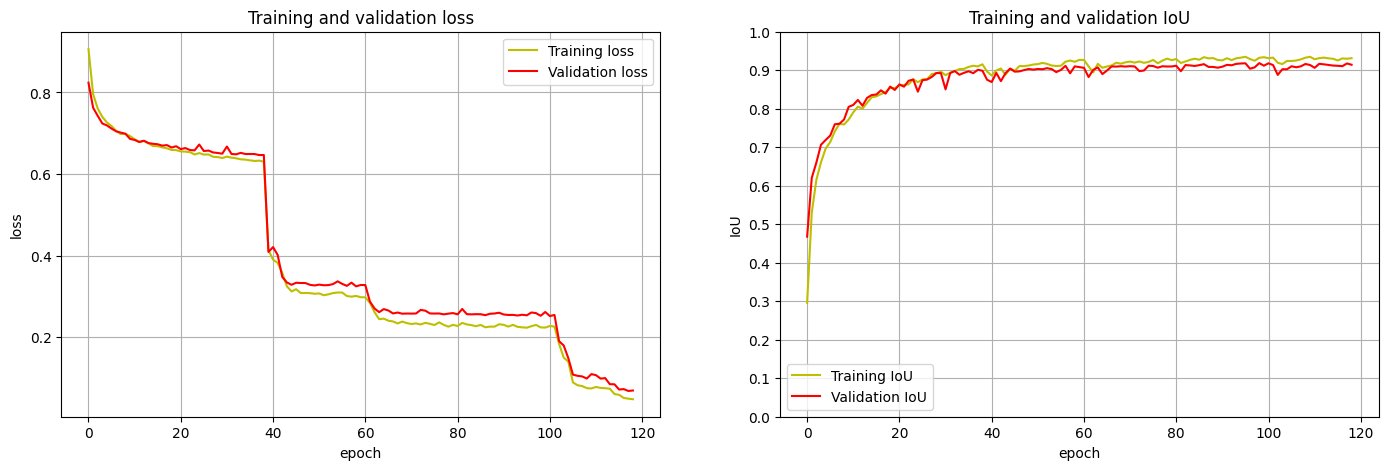

In [ ]:
def plotModel(history, save=None):
    plt.figure(figsize=(17, 5))
    plt.subplot(1, 2, 1)
    plt.plot([h.get('train_loss') for h in history], 'y', label='Training loss')
    plt.plot([h.get('val_loss') for h in history], 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'), plt.ylabel('loss')
    plt.legend(), plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot([h.get('train_iou') for h in history], 'y', label='Training IoU')
    plt.plot([h.get('val_iou') for h in history], 'r', label='Validation IoU')
    plt.title('Training and validation IoU')
    plt.xlabel('epoch'), plt.ylabel('IoU')
    plt.legend(), plt.grid(), plt.gca().set_ylim(0, 1), plt.yticks([c/10 for c in range(11)])

    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


plotModel(trainer.history)

# DADOS DE TESTE

In [ ]:
test_loss, test_iou = trainer.evaluate(loader=testLoader)
test_iou

0.9133224487304688

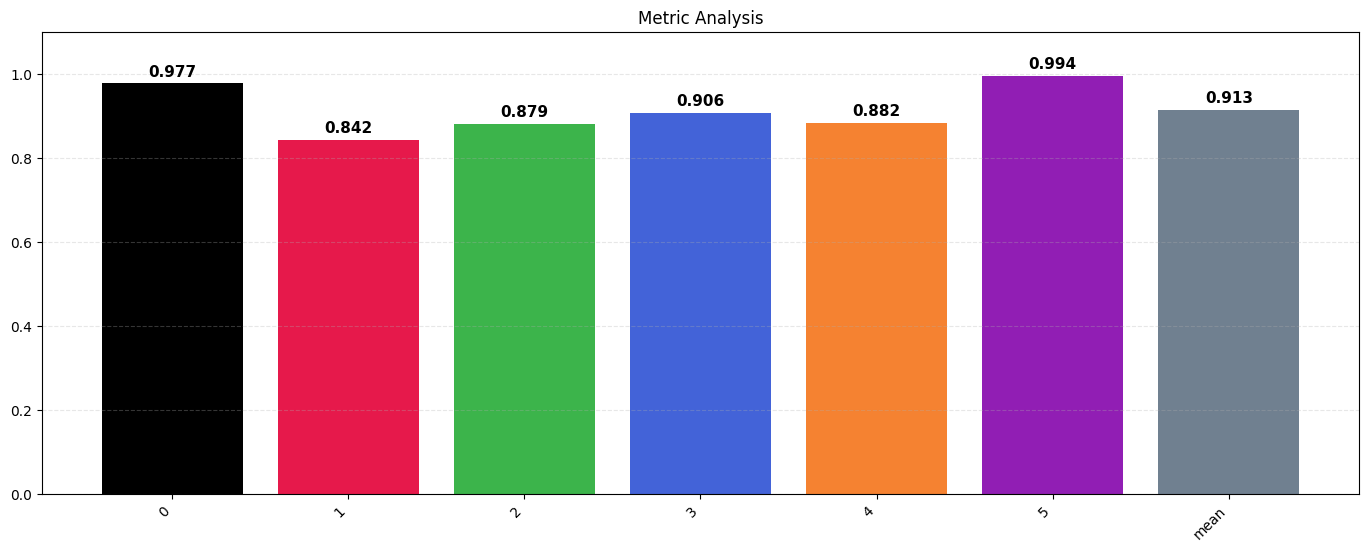

In [ ]:
from torchmetrics.classification import MulticlassJaccardIndex


def getClasses(network, loader, save=None):
    iou_por_classe = MulticlassJaccardIndex(num_classes=network.classes, average='none').to(network.device)
    network.model.eval()

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(network.device)
            masks = masks.to(network.device).squeeze(1)

            logits = network.model(imgs)
            preds  = torch.argmax(logits, dim=1)
            iou_por_classe.update(preds, masks)

    ious = iou_por_classe.compute().cpu().numpy()
    ious = {str(i): float(val) for i, val in enumerate(ious)}

    class_keys = sorted([k for k in ious.keys() if k != 'mean'], key=lambda x: int(x) if x.isdigit() else x)
    sorted_ious = {k: ious[k] for k in class_keys}
    sorted_ious.update({'mean': test_iou})

    plt.figure(figsize=(17, 6))
    Plotter(sorted_ious)

    if save:
        plt.savefig(save)
        plt.close()

    return ious


if network.multiclass:
    getClasses(network, testLoader)
    plt.show()

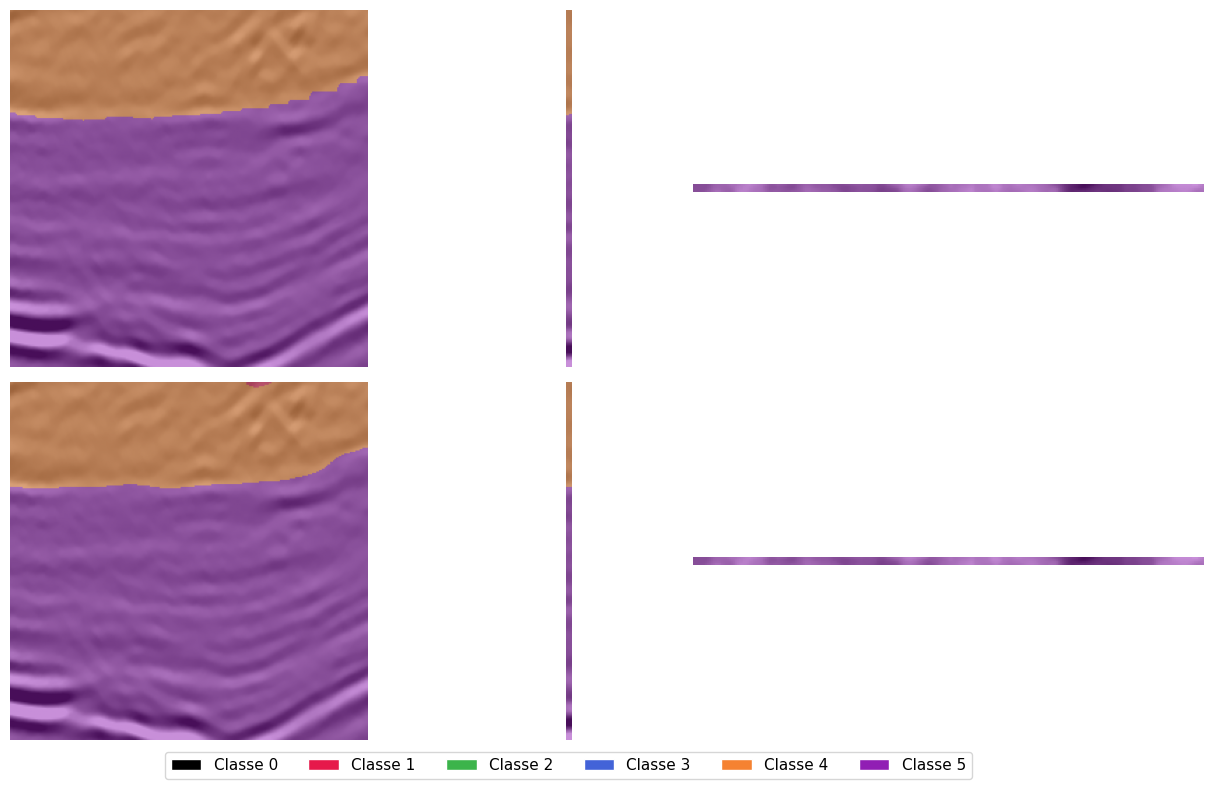

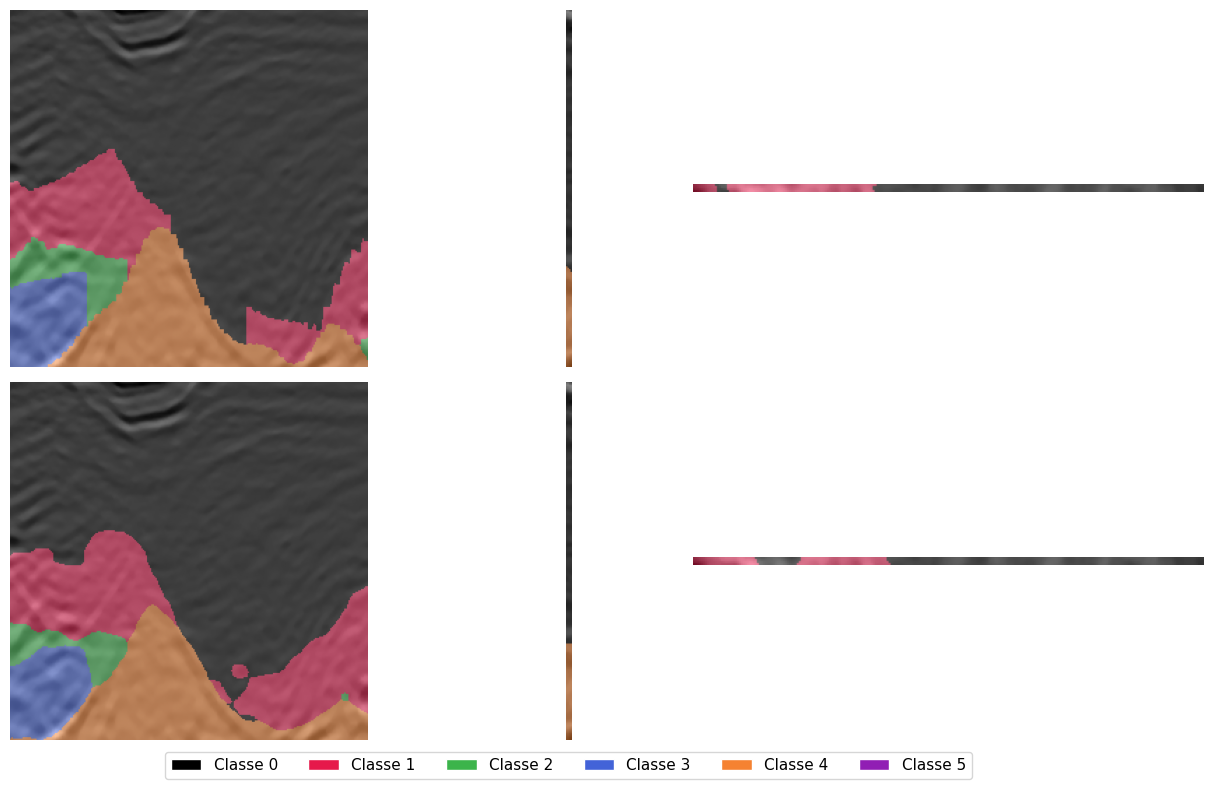

In [ ]:
def plotPrediction(index, dataset=testDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits = network.model(img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    if network.multiclass:
        solid_cmap, cmap = faciesCmaps(network.classes)
        mx, my, mz = img_np.shape[0] // 2, img_np.shape[1] // 2, img_np.shape[2] // 2
        planes = lambda v: [np.array(v[mx, :, :]), np.rot90(np.array(v[:, :, mz]), -1), np.array(v[:, my, :])]
        ig, mg, pg = planes(img_np), planes(mask_np), planes(pred_np)

        fig, axes = plt.subplots(2, 3, figsize=(13, 8))
        for j in range(3):
            for r, layer in enumerate([mg, pg]):
                axes[r, j].imshow(ig[j], cmap='gray')
                axes[r, j].imshow(layer[j], cmap=cmap, vmin=0, vmax=network.classes - 1, alpha=alpha)
                axes[r, j].axis('off')

        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=solid_cmap.colors[i], edgecolor='white', label=f'Classe {i}') for i in range(network.classes)]
        fig.legend(handles=legend_elements, loc='lower center', ncol=min(network.classes, 7), bbox_to_anchor=(0.5, 0.01), fontsize=11)

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        if savePath:
            plt.savefig(savePath, bbox_inches='tight', dpi=200); plt.close(fig)
        else:
            plt.show()
        return

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    inters  = (is_gt & is_pred)

    overlay[is_gt]   = [0, 0, 255]
    overlay[is_pred] = [255, 0, 0]
    overlay[inters]  = [0, 255, 0]

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)


for i in range(min(len(testDataset), 2)):
    plotPrediction(index=i, dataset=testDataset, network=network)

# SALVANDO O MODELO

In [ ]:
from datetime import datetime
import json, inspect

In [ ]:
os.makedirs('Backup/', exist_ok=True)
files   = [f for f in os.listdir('Backup/') if f.startswith('model_')]
indexes = sorted([int(path.split('_')[-1]) for path in files]) if len(files) > 0 else [0]
index   = indexes[-1] + 1
folder  = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

'Backup/model_15'

In [ ]:
iouData = getClasses(network, testLoader, save=os.path.join(folder, 'classes.png')) if network.multiclass else {'mean': test_iou}
path    = os.path.join(folder, 'predictions')
os.makedirs(path, exist_ok=True)

for i in range(min(len(testDataset), 20)):
    plotPrediction(index=i, dataset=testDataset, network=network, savePath=os.path.join(path, f'pred_{i}.png'))

In [ ]:
model_info = {
    'trainer': {
        'path': f'model_{index}',
        'loss': selected_loss,
        'scheduler': scheduler,
        'epochs': trainer.epochs,
        'batch_size': BATCH_SIZE,
        'gpus': len(network.gpu_ids),
        'val_iou':  trainer.history[-1].get('val_iou'),
        'test_iou': test_iou
    },

    'processing': OPTIONS,
    'model': model_options,
    'iou': iouData
}

model_data = {
    'model': network.module.state_dict(),   # pesos sem o wrapper DataParallel: mesmo formato de sempre
    'optimizer': network.optimizer.state_dict(),
    'timestamp': datetime.now().strftime('%d/%m/%y %H:%M:%S'),
    'history': trainer.history,
}

with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(model_info, file, ensure_ascii=False, indent=4)

plotModel(model_data['history'], save=os.path.join(folder, 'train.png'))
torch.save(model_data, f'{folder}/model.pth')
print('model saved in', folder)

model saved in Backup/model_15
